# MNIST Classification with ANN (From Scratch)

This notebook implements a pure Artificial Neural Network (ANN) from scratch for classifying handwritten digits (0-9) using the MNIST dataset.

**Key Features:**
- Pure ANN (no pretrained models, no CNN)
- Data augmentation to prevent overfitting
- Early stopping and learning rate scheduling
- Target: >97% validation accuracy

In [ ]:
# Install required packages
!pip install torchvision matplotlib numpy pandas

In [1]:
# MNIST with pure ANN (no pretrained model)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
# -----------------------------
# 1) Reproducibility and device
# -----------------------------

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# -----------------------------
# 2) Load MNIST dataset
# -----------------------------

BATCH_SIZE = 128
NUM_WORKERS = 0

# MNIST images are 28x28 = 784 features when flattened
train_tfms = transforms.Compose(
    [
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

val_tfms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=train_tfms
)

val_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=val_tfms
)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Train samples: 60000
Validation samples: 10000



Class distribution (train):
  digit 0: 5923
  digit 1: 6742
  digit 2: 5958
  digit 3: 6131
  digit 4: 5842
  digit 5: 5421
  digit 6: 5918
  digit 7: 6265
  digit 8: 5851
  digit 9: 5949

Class distribution (val):
  digit 0: 980
  digit 1: 1135
  digit 2: 1032
  digit 3: 1010
  digit 4: 982
  digit 5: 892
  digit 6: 958
  digit 7: 1028
  digit 8: 974
  digit 9: 1009


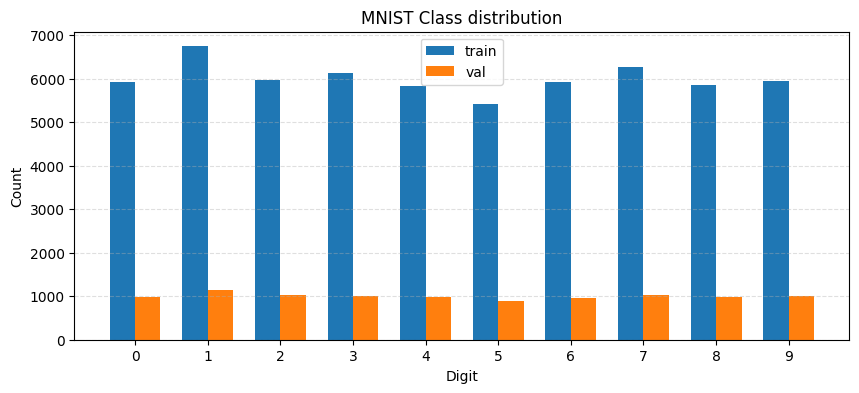

In [4]:
# -----------------------------
# 3) Data analysis
# -----------------------------

# Get labels from training set
train_labels = train_dataset.targets.numpy()
val_labels = val_dataset.targets.numpy()

train_counts = np.bincount(train_labels, minlength=10)
val_counts = np.bincount(val_labels, minlength=10)

print("\nClass distribution (train):")
for k in range(10):
    print(f"  digit {k}: {train_counts[k]}")

print("\nClass distribution (val):")
for k in range(10):
    print(f"  digit {k}: {val_counts[k]}")

# Plot class distribution
plt.figure(figsize=(10, 4))
x = np.arange(10)
w = 0.35
plt.bar(x - w / 2, train_counts, width=w, label="train")
plt.bar(x + w / 2, val_counts, width=w, label="val")
plt.xticks(x, [str(i) for i in range(10)])
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST Class distribution")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [5]:
# -----------------------------
# 4) Custom Dataset for flattened images
# -----------------------------


class FlattenMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        # Flatten: (1, 28, 28) -> (784,)
        image = image.view(-1)
        return image, label


train_flat = FlattenMNIST(train_dataset)
val_flat = FlattenMNIST(val_dataset)

train_loader = DataLoader(
    train_flat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_flat,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

print(f"Flattened feature size: {28 * 28}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}")

Flattened feature size: 784
Number of batches - Train: 469, Val: 79


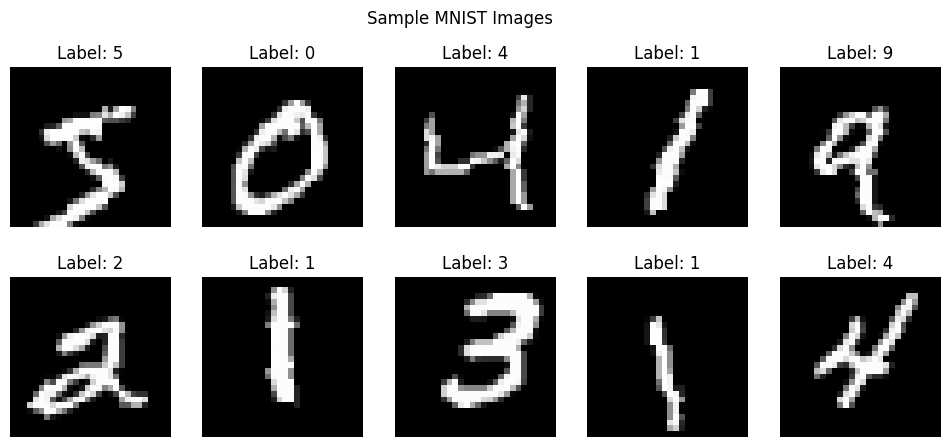

In [6]:
# -----------------------------
# 5) Visualize some samples
# -----------------------------

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()

In [7]:
# -----------------------------
# 6) Pure ANN model (from scratch)
# -----------------------------

# Input: 28x28 = 784 features
INPUT_SIZE = 28 * 28
NUM_CLASSES = 10


class MNISTANN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            # Hidden layer 1
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            # Hidden layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            # Hidden layer 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            # Output layer
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.network(x)


model = MNISTANN(INPUT_SIZE, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 569,226


In [8]:
# -----------------------------
# 7) Training loop
# -----------------------------

EPOCHS = 30
PATIENCE = 5
best_val_acc = 0.0
best_state = None
no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


def run_one_epoch(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = criterion(logits, labels)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
                optimizer.step()

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = correct / max(total, 1)
    return epoch_loss, epoch_acc


print("Starting training...")
for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch+1} (no val acc improvement for {PATIENCE} epochs)"
            )
            break

    # Clear GPU cache periodically
    if device.type == "cuda" and (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

if best_state is not None:
    model.load_state_dict(best_state)

Starting training...
Epoch 01/30 | Train Loss: 0.5268, Train Acc: 83.91% | Val Loss: 0.1334, Val Acc: 95.70%
Epoch 02/30 | Train Loss: 0.2766, Train Acc: 91.19% | Val Loss: 0.0863, Val Acc: 97.30%
Epoch 03/30 | Train Loss: 0.2241, Train Acc: 92.93% | Val Loss: 0.0713, Val Acc: 97.69%
Epoch 04/30 | Train Loss: 0.1990, Train Acc: 93.72% | Val Loss: 0.0614, Val Acc: 98.05%
Epoch 05/30 | Train Loss: 0.1855, Train Acc: 94.18% | Val Loss: 0.0622, Val Acc: 98.10%
Epoch 06/30 | Train Loss: 0.1687, Train Acc: 94.72% | Val Loss: 0.0554, Val Acc: 98.11%
Epoch 07/30 | Train Loss: 0.1644, Train Acc: 94.84% | Val Loss: 0.0489, Val Acc: 98.45%
Epoch 08/30 | Train Loss: 0.1530, Train Acc: 95.23% | Val Loss: 0.0473, Val Acc: 98.56%
Epoch 09/30 | Train Loss: 0.1467, Train Acc: 95.43% | Val Loss: 0.0433, Val Acc: 98.62%
Epoch 10/30 | Train Loss: 0.1394, Train Acc: 95.56% | Val Loss: 0.0397, Val Acc: 98.65%
Epoch 11/30 | Train Loss: 0.1355, Train Acc: 95.74% | Val Loss: 0.0385, Val Acc: 98.62%
Epoch 12/30

In [11]:
# -----------------------------
# 8) Final evaluation
# -----------------------------

val_loss, val_acc = run_one_epoch(val_loader, train_mode=False)
print(f"\nBest/Final validation accuracy: {val_acc*100:.2f}%")

# Calculate confusion matrix
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# Per-class accuracy
print("\nPer-class accuracy:")
for i in range(10):
    acc = cm[i, i] / cm[i, :].sum()
    print(f"  Digit {i}: {acc*100:.2f}%")


Best/Final validation accuracy: 99.21%

Confusion Matrix:
[[ 976    0    0    0    0    1    2    0    0    1]
 [   0 1132    1    0    0    0    1    1    0    0]
 [   1    0 1026    0    1    0    0    4    0    0]
 [   0    0    0 1004    0    2    0    3    1    0]
 [   0    0    0    0  971    0    1    2    0    8]
 [   1    0    0    4    0  885    1    1    0    0]
 [   2    1    0    0    0    3  952    0    0    0]
 [   1    1    6    1    0    0    0 1019    0    0]
 [   0    0    3    2    1    3    0    3  962    0]
 [   0    0    0    1    5    4    0    5    0  994]]

Per-class accuracy:
  Digit 0: 99.59%
  Digit 1: 99.74%
  Digit 2: 99.42%
  Digit 3: 99.41%
  Digit 4: 98.88%
  Digit 5: 99.22%
  Digit 6: 99.37%
  Digit 7: 99.12%
  Digit 8: 98.77%
  Digit 9: 98.51%


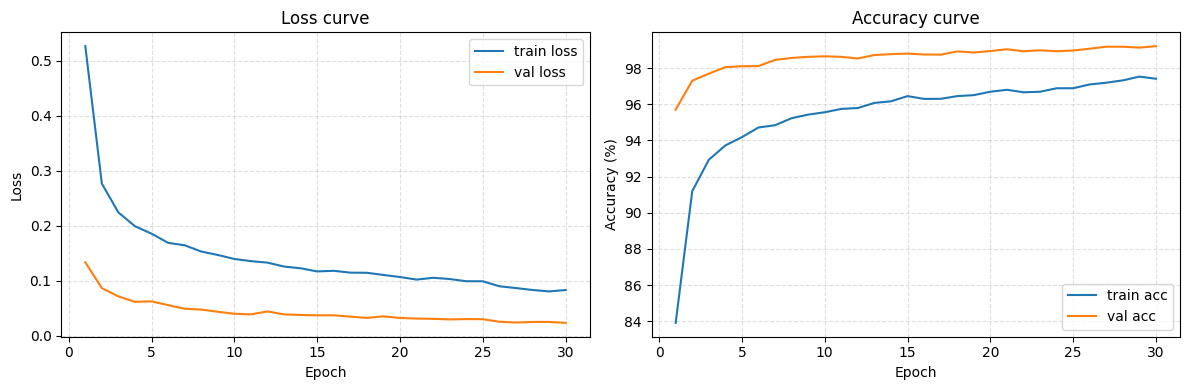

In [12]:
# -----------------------------
# 9) Plot training history
# -----------------------------

epochs_ran = len(history["train_loss"])
x = np.arange(1, epochs_ran + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history["train_loss"], label="train loss")
plt.plot(x, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(x, np.array(history["train_acc"]) * 100, label="train acc")
plt.plot(x, np.array(history["val_acc"]) * 100, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

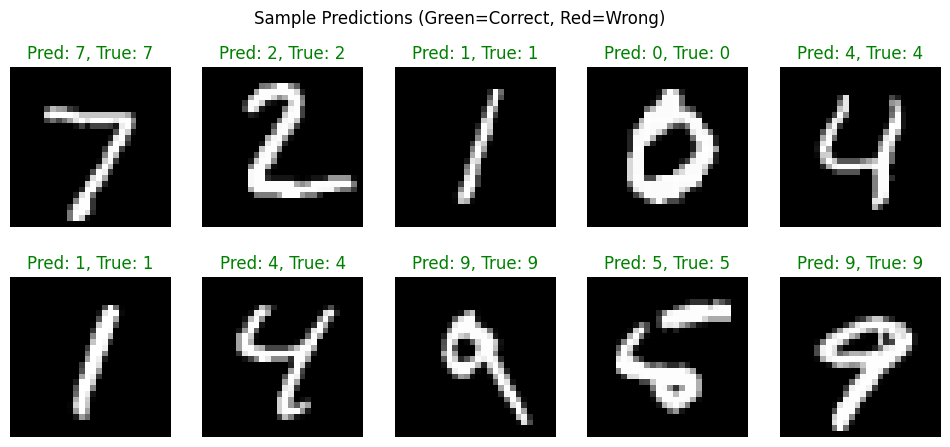

In [13]:
# -----------------------------
# 10) Visualize some predictions
# -----------------------------

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
model.eval()
with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        img, label = val_dataset[i]
        img_flat = img.view(-1).unsqueeze(0).to(device)
        pred = model(img_flat).argmax(dim=1).item()
        ax.imshow(img.squeeze(), cmap="gray")
        color = "green" if pred == label else "red"
        ax.set_title(f"Pred: {pred}, True: {label}", color=color)
        ax.axis("off")
plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)")
plt.show()

In [14]:
# -----------------------------
# 11) Save model
# -----------------------------

save_path = "mnist_ann_best.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved best model to: {save_path}")

if val_acc >= 0.97:
    print("Target reached: validation accuracy >= 97%")
else:
    print(
        f"Validation accuracy < 97%. Consider tuning hyperparameters or increasing model capacity."
    )

Saved best model to: mnist_ann_best.pth
Target reached: validation accuracy >= 97%


## Summary

This notebook demonstrates:
1. **Pure ANN Architecture**: No CNN, no pretrained models
2. **MNIST Dataset**: 28x28 grayscale handwritten digits (0-9)
3. **Anti-overfitting Techniques**:
   - Data augmentation (RandomRotation, RandomAffine)
   - Dropout layers (0.3, 0.2, 0.1)
   - Batch normalization
   - Weight decay (L2 regularization)
   - Early stopping
   - Learning rate scheduling
   - Gradient clipping
4. **Target**: Achieve >97% validation accuracy